In [1]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
import mne
from scipy.optimize import minimize
from scipy.stats import norm, skewnorm
from math import ceil
import pandas as pd

from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss, brier_score_loss


repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

# Upload data

In [2]:
task = 'Active'
file_path = f'Fit_{task}_late'
os.makedirs(file_path, exist_ok=True)

models_dict, trajectories_dict, binarized_audibilities_dict = {}, {}, {}
    
for part in tqdm(range(20)):

    # Load data
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref

    # Load metadata
    epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
    audibility = epochs.metadata['audibility'].to_numpy()
    snr = epochs.metadata['snr'].to_numpy()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train = lead.STG(epochs_file, tmin=300, tmax=500, sort_by_snr=True)
        trajectories_dict[part] = state_train
        n_categories = len(list(state_train.keys()))
        categories = list(range(n_categories))

    # sort audibilities according to SNR
    sorted_audibilities = {cat: [] for cat in categories}
    binarized_audibilities = {cat: [] for cat in categories}
    for cat in categories:
        cat_indices = np.where(snr == (cat + 1))[0]
        sorted_audibilities[cat] = audibility[cat_indices]
        binarized_audibilities[cat] = (sorted_audibilities[cat] >= 2).astype(int)
    binarized_audibilities_dict[part] = binarized_audibilities

    # load model parameters 
    model = lead.model.StratifiedGainModulation(
        tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5)
    param_path = file_path + f"/GainModulatedModel_part{part}_params"
    model.load_params(param_path)
    models_dict[part] = model

  0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_79461/831752060.py:14: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_79461/831752060.py:14: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_79461/831752060.py:14: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_79461/831752060.py:14: RuntimeWarning: The 

# Simulate trajectories from fitted models

In [3]:
simul_trajectories_dict = {}
n_trials = 10000
for part in tqdm(range(20)):
    categories = list(trajectories_dict[part].keys())
    one_input = np.concatenate((np.zeros(75), np.ones(25), np.zeros(150)))
    input_series = {cat: np.stack([one_input for _ in range(n_trials)]) for cat in categories}
    model = models_dict[part]
    measures = model.measure_simulations(input_series=input_series) #, initial_states = {cat: np.repeat(trajectories_dict[part][cat][:, 75].flatten(), 5) for cat in categories})
    simul_trajectories_dict[part] = measures

  0%|          | 0/20 [00:00<?, ?it/s]

# Infer Mixture parameters

In [4]:
def FitMixture(model, simul_distributions, n, fix_resting_state=True, alpha_continuity_penalty_coef=0, fix_lambda_to_zero=True, dt=1, verbose=False):
    '''
    <model> : a fitted StratifiedGainModulation model
    <simul_distributions> : a dictionary of measured distributions for each category, with no time dimension {cat: 1D_array}
    <n> : number of time-points averaged to obtain the measured distributions
    <fix_resting_state> : if True, the resting state mean is fixed to 0
    <alpha_continuity_penalty_coef> : coefficient for the penalty term to encourage continuity in alpha values
    <fix_lambda_to_zero> : if True, lambda is fixed to 0 (the mixture is an actual Gaussian Mixture); if False, lambda is allowed to vary (the upper distribution is a skewed Gaussian)
    <dt> : time step for the simulation
    <verbose> : if True, print verbose output
    '''

    # Pull fitted model parameters
    params = model.get_params()
    tau = float(params['tau'])
    sigma_q = float(params['process_noise'])
    sigma_r = float(params['measure_noise'])

    # Calculate shared resting-state spread (time-averaged)
    rho = np.exp(-dt / tau)
    ou_variance_avg = (tau * (sigma_q ** 2) / (2.0 * n)) * \
                    ((1.0 + rho) / (1.0 - rho) - (2.0 * rho * (1.0 - rho**n)) / (n * (1.0 - rho)**2))
    measure_variance_avg = (sigma_r ** 2) / n
    sigma_rest = np.sqrt(ou_variance_avg + measure_variance_avg)

    # Define categories
    categories = list(simul_distributions.keys())
    fit_categories = categories[1:]
    num_fit_cats = len(fit_categories)


    # --- 1. Precompute fixed parameters, bounds, and initial values ---

    mu_rest_dict = {0: params['w0'] * tau}     # mu0 = 0 because w0 = 0 for the resting state
    data_dict = {0: np.asarray(simul_distributions[0], dtype=float)}

    bounds_alphas = []
    bounds_mu1s = []
    bounds_log_sigmas = []
    init_mu1s = []
    for cat in fit_categories:
        x = np.asarray(simul_distributions[cat], dtype=float)
        data_dict[cat] = x
        mu_rest_dict[cat] = params[f'w{cat}'] * tau if not fix_resting_state else 0.0
        init_mu1s.append(np.mean(x))
        bounds_alphas.append((1e-4, 1.0 - 1e-4))
        bounds_mu1s.append((0, 3))
        bounds_log_sigmas.append((np.log(1e-4), np.log(10.0)))
    bounds_lambdas = [(0.0, 0.0)] * num_fit_cats if fix_lambda_to_zero else [(-8.0, 0.0)] * num_fit_cats

    init_alphas = np.linspace(0.9, 0.1, num_fit_cats).tolist()
    init_log_sigmas = [np.log(sigma_rest)] * num_fit_cats
    init_lambdas = [-1.0] * num_fit_cats

    # aggregate init points and bounds for scipy.optimize.minimize
    init_theta = np.array(init_alphas + init_mu1s + init_log_sigmas + init_lambdas, dtype=float)
    bounds = bounds_alphas + bounds_mu1s + bounds_log_sigmas + bounds_lambdas

    # --- 2. Define the Joint Negative Log-Likelihood ---

    def joint_nll(theta):

        alphas     = theta[:num_fit_cats]
        mu1s       = theta[num_fit_cats:2*num_fit_cats]
        log_sigmas = theta[2*num_fit_cats:3*num_fit_cats]
        lambdas    = theta[3*num_fit_cats:4*num_fit_cats]

        total_nll = 0.0
        for i, cat in enumerate(fit_categories):

            x = data_dict[cat]
            mu0    = mu_rest_dict[cat]
            alpha  = alphas[i]
            mu1    = mu1s[i]
            sigma1 = np.exp(log_sigmas[i])
            lam    = lambdas[i]

            p0 = norm.pdf(x, loc=mu0, scale=sigma_rest)
            p1 = skewnorm.pdf(x, a=lam, loc=mu1, scale=sigma1)
            p  = alpha * p0 + (1.0 - alpha) * p1
            total_nll -= np.sum(np.log(np.maximum(p, 1e-300)))

        # add a potential penalty for discontinuous solutions
        if alpha_continuity_penalty_coef != 0.0:
            alpha_full = np.empty(len(categories), dtype=float)
            alpha_full[0] = 1.0
            for i, cat in enumerate(fit_categories):
                alpha_full[cat] = alphas[i]
            alpha_diffs = np.diff(alpha_full)
            total_nll += alpha_continuity_penalty_coef * np.sum(alpha_diffs ** 2) / len(alpha_diffs)

        return total_nll


    # --- 3. Define Constraints ---

    constraints = []

    # alpha decreasing
    for i in range(num_fit_cats - 1):
        constraints.append({'type': 'ineq', 'fun': lambda theta, i=i: theta[i] - theta[i + 1]})

    # mu1 increasing
    for i in range(num_fit_cats - 1):
        constraints.append({'type': 'ineq', 'fun': lambda theta, i=i: theta[num_fit_cats + i + 1] - theta[num_fit_cats + i]})

    # lambda decreasing
    if not fix_lambda_to_zero:
        for i in range(num_fit_cats - 1):
            constraints.append({
                'type': 'ineq',
                'fun': lambda theta, i=i,: theta[3*num_fit_cats + i] - theta[3*num_fit_cats + i + 1]  # i >= i+1
            })

    # --- 4. Run Joint Optimization ---

    result = minimize(
        joint_nll,
        init_theta,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 1000, 'ftol': 1e-6}
    )


    # --- 5. Extract and Format Results ---

    opt_alphas  = result.x[0:num_fit_cats]
    opt_mu1s    = result.x[num_fit_cats : 2*num_fit_cats]
    opt_sigmas  = np.exp(result.x[2*num_fit_cats:3*num_fit_cats])
    opt_lambdas = result.x[3*num_fit_cats:4*num_fit_cats]

    mixture_fits = {
        0: {
            'alpha': 1.0,
            'mu1': mu_rest_dict[0],
            'sigma1': sigma_rest,
            'mu0': mu_rest_dict[0],
            'sigma0': sigma_rest,
            'lambda': float(opt_lambdas[0])
        }
    }
    for i, cat in enumerate(fit_categories):
        mixture_fits[cat] = {
            'alpha': float(opt_alphas[i]),
            'mu1': float(opt_mu1s[i]),
            'sigma1': float(opt_sigmas[i]),
            'mu0': mu_rest_dict[cat],
            'sigma0': sigma_rest,
            'lambda': float(opt_lambdas[i])
        }


    if verbose:
        print(f"Joint Optimization Success: {result.success}")
        print(f"Total Joint NLL: {result.fun:.2f}")
        print(f"Alpha continuity penalty coef: {alpha_continuity_penalty_coef}")
        print(f"Shared rest sigma (averaged over n={n}): {sigma_rest:.4f}")
        print(f"Per-category lambdas: {[f'{l:.4f}' for l in opt_lambdas]} (fix_lambda_to_zero={fix_lambda_to_zero})\n")
        for cat in categories:
            f = mixture_fits[cat]
            print(f"Cat {cat}: alpha={f['alpha']:.3f}, mu0={f['mu0']:.3f}, " f"mu1={f['mu1']:.3f}, sigma1={f['sigma1']:.3f}, lambda={f['lambda']:.3f}")


    return mixture_fits

# Compute behavioral predictions AUC

In [5]:
def model2behaviorAUC(mixture_fits, binarized_audibilities, empirical_distributions):

    binary_true_all = []
    binary_prob_all = []

    for cat in list(mixture_fits.keys())[1:]:
        y_true = np.asarray(binarized_audibilities[cat], dtype=int)
        fit = mixture_fits[cat]
        x = np.asarray(empirical_distributions[cat], dtype=float)

        # Bayesian prediction based on the mixture parameters
        lam = fit['lambda']
        p_rest = fit['alpha'] * norm.pdf(x, loc=fit['mu0'], scale=fit['sigma0'])
        p_alt  = (1.0 - fit['alpha']) * skewnorm.pdf(x, a=lam, loc=fit['mu1'], scale=fit['sigma1'])
        p_class1 = p_alt / np.maximum(p_rest + p_alt, 1e-300)

        binary_true_all.append(y_true)
        binary_prob_all.append(p_class1)

    y_true_all = np.concatenate(binary_true_all)
    y_prob_all = np.concatenate(binary_prob_all)
    
    return roc_auc_score(y_true_all, y_prob_all)


In [6]:
mixture_fits_dict, auc_dict = {}, {}
for part in [18]: #tqdm(range(20)):

    # Fit mixture model to the simulated distributions
    model = models_dict[part]
    simul_distributions = {cat: np.mean(simul_trajectories_dict[part][cat][:, 90:100], axis=-1).flatten() for cat in simul_trajectories_dict[part]}
    fit_mixture = FitMixture(model, simul_distributions, n=10, fix_resting_state=True, alpha_continuity_penalty_coef=0, fix_lambda_to_zero=True, dt=1, verbose=False)

    # Evaluate the mixture model's predictions against the empirical distributions and behavioral data
    distributions = {cat: np.mean(trajectories_dict[part][cat][:, 90:100], axis=-1).flatten() for cat in categories}
    auc = model2behaviorAUC(fit_mixture, binarized_audibilities_dict[part], distributions)

    mixture_fits_dict[part] = fit_mixture
    auc_dict[part] = auc
print(auc_dict)

/home/thardy/soundmodelenv/lib/python3.11/site-packages/scipy/optimize/_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


{18: 0.8417949784990985}


# Compute AUC through time

  0%|          | 0/20 [00:00<?, ?it/s]

Part 0:   0%|          | 0/100 [00:00<?, ?it/s]

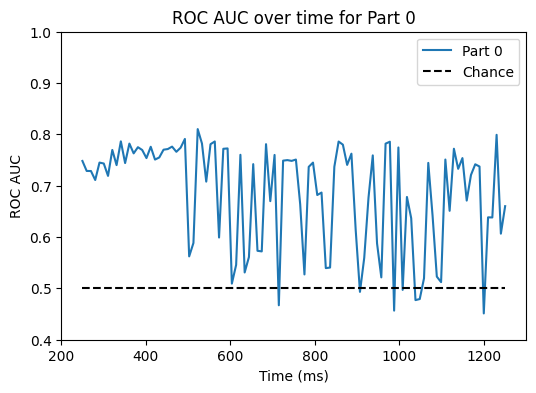

Part 1:   0%|          | 0/100 [00:00<?, ?it/s]

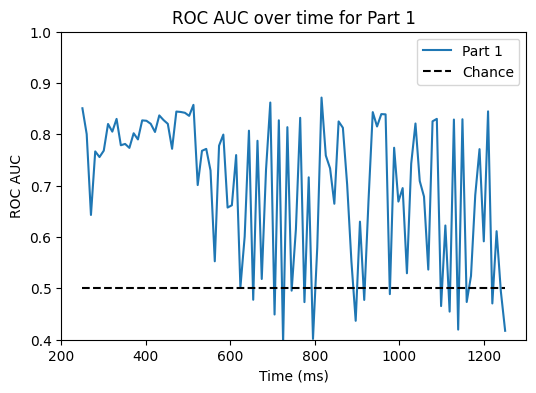

Part 2:   0%|          | 0/100 [00:00<?, ?it/s]

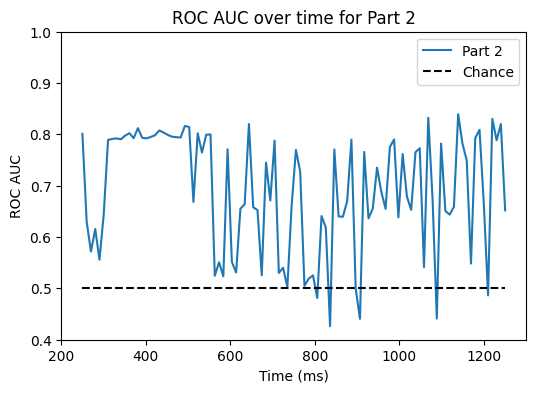

Part 3:   0%|          | 0/100 [00:00<?, ?it/s]

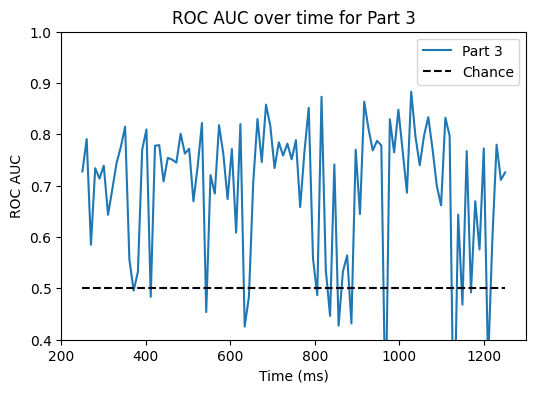

Part 4:   0%|          | 0/100 [00:00<?, ?it/s]

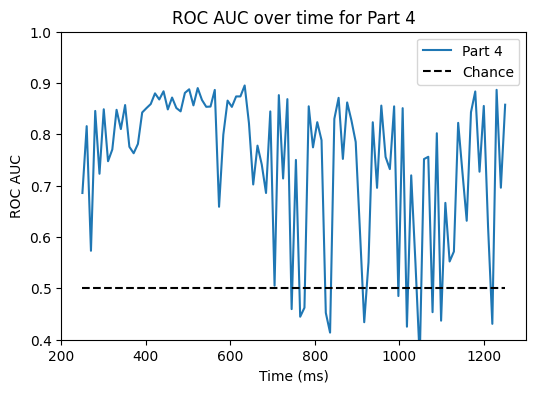

Part 5:   0%|          | 0/100 [00:00<?, ?it/s]

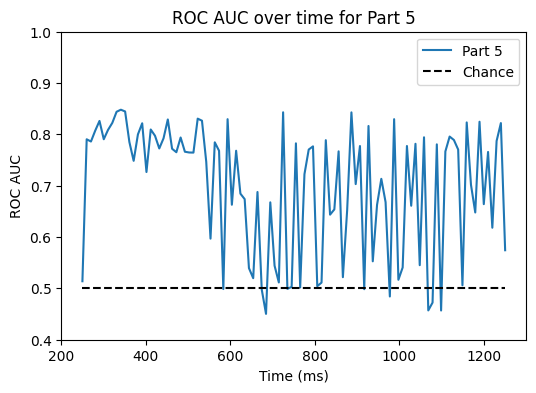

Part 6:   0%|          | 0/100 [00:00<?, ?it/s]

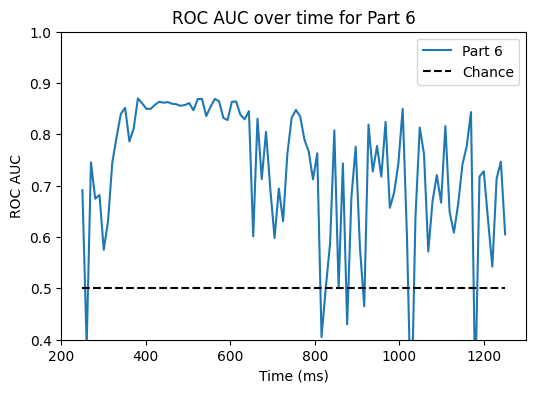

Part 7:   0%|          | 0/100 [00:00<?, ?it/s]

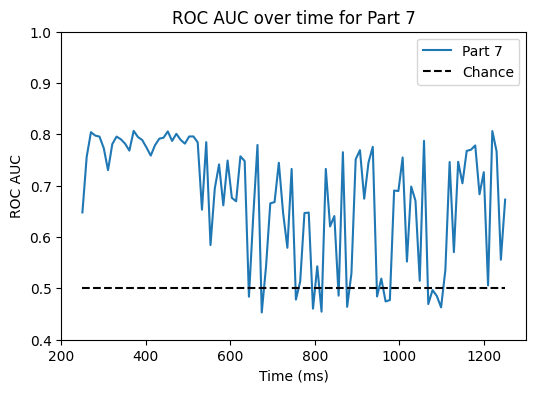

Part 8:   0%|          | 0/100 [00:00<?, ?it/s]

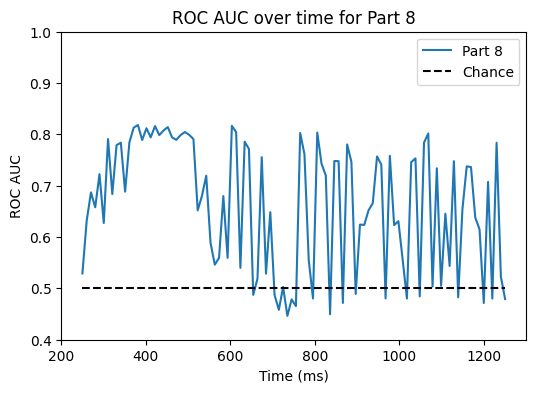

Part 9:   0%|          | 0/100 [00:00<?, ?it/s]

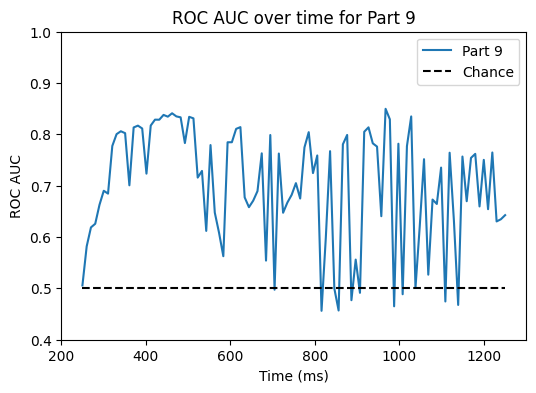

Part 10:   0%|          | 0/100 [00:00<?, ?it/s]

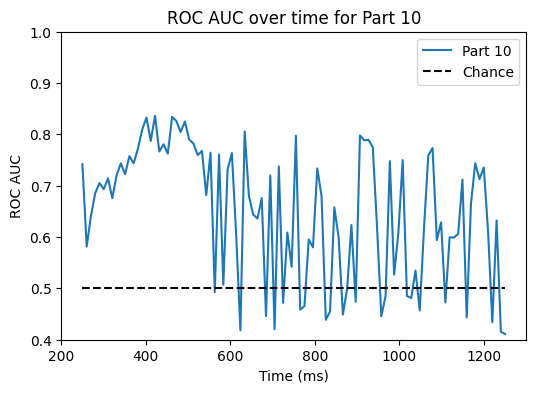

Part 11:   0%|          | 0/100 [00:00<?, ?it/s]

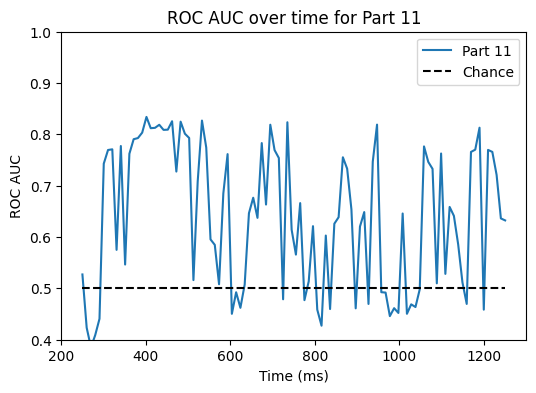

Part 12:   0%|          | 0/100 [00:00<?, ?it/s]

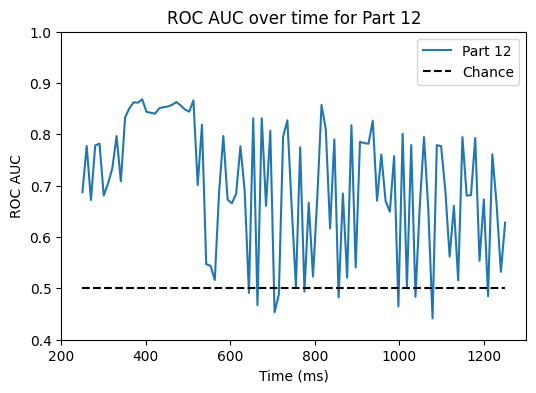

Part 13:   0%|          | 0/100 [00:00<?, ?it/s]

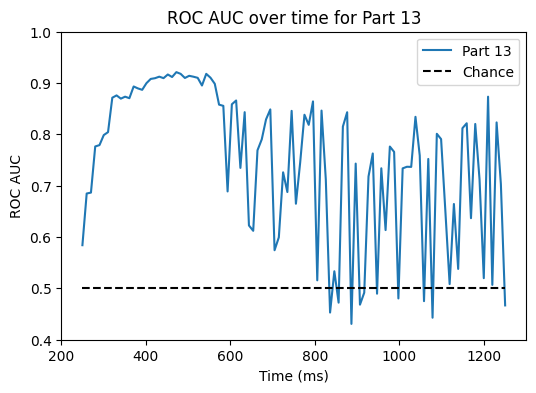

Part 14:   0%|          | 0/100 [00:00<?, ?it/s]

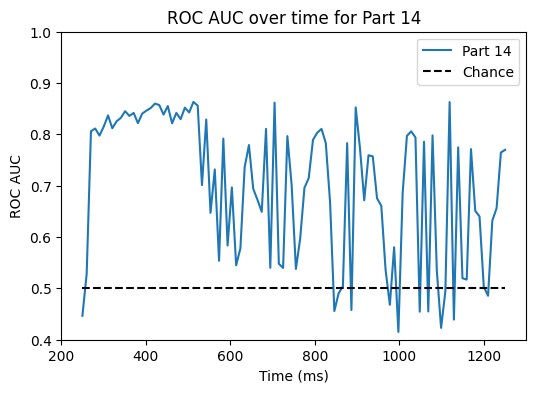

Part 15:   0%|          | 0/100 [00:00<?, ?it/s]

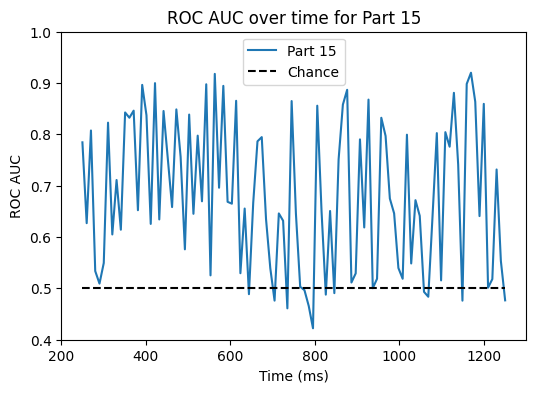

Part 16:   0%|          | 0/100 [00:00<?, ?it/s]

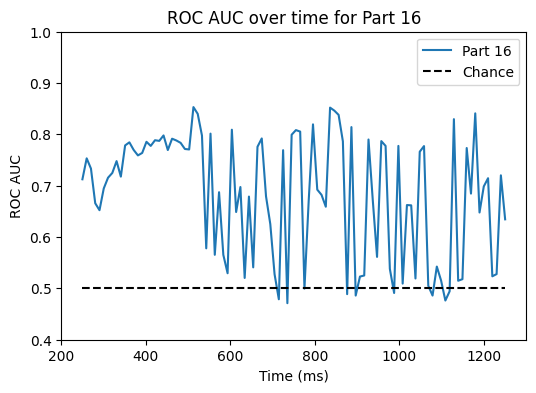

Part 17:   0%|          | 0/100 [00:00<?, ?it/s]

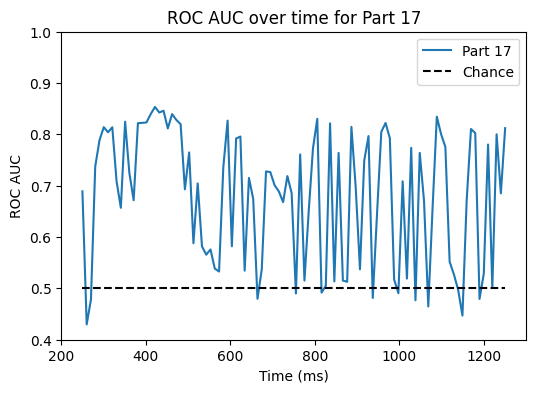

Part 18:   0%|          | 0/100 [00:00<?, ?it/s]

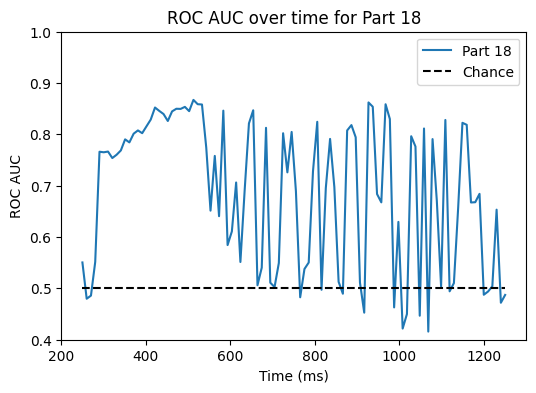

Part 19:   0%|          | 0/100 [00:00<?, ?it/s]

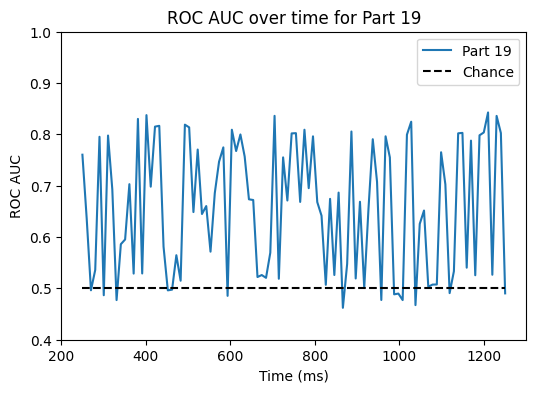

/tmp/ipykernel_79461/1404980828.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


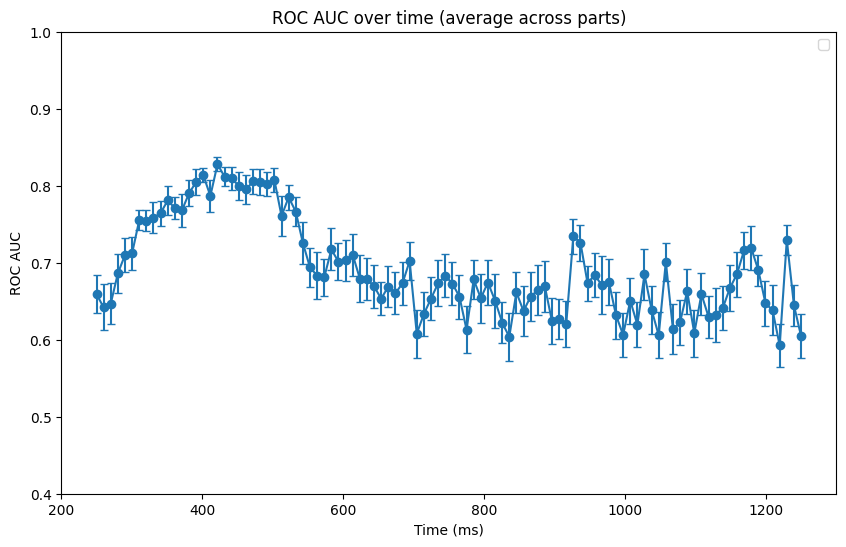

In [7]:
import warnings
warnings.filterwarnings(
    "ignore", 
    message="Values in x were outside bounds during a minimize step, clipping to bounds"
)

save_folder = 'Behavioral_Predictions_InTime'
# os.makedirs(save_folder, exist_ok=True)

times = np.linspace(250, 1250, 100)
auc_series = {}
mixture_series = {}
for part in tqdm(range(20)):

    model = models_dict[part]
    auc_serie_this_part = []
    mixture_serie_this_part = []
    for t_ind in tqdm(range(100), desc=f"Part {part}", leave=False):

        # simul_distributions = {cat: np.mean(simul_trajectories_dict[part][cat][:, 90:100], axis=-1).flatten() for cat in simul_trajectories_dict[part]}
        simul_distributions = {cat: simul_trajectories_dict[part][cat][:, 75+t_ind].flatten() for cat in simul_trajectories_dict[part]}
        fit_mixture = FitMixture(model, simul_distributions, n=1, fix_resting_state=True, alpha_continuity_penalty_coef=0, fix_lambda_to_zero=False, dt=1, verbose=False)
        distributions = {cat: trajectories_dict[part][cat][:, 75+t_ind].flatten() for cat in categories}
        auc = model2behaviorAUC(fit_mixture, binarized_audibilities_dict[part], distributions)
        auc_serie_this_part.append(auc)
        mixture_serie_this_part.append(fit_mixture)

    auc_series[part] = auc_serie_this_part
    mixture_series[part] = mixture_serie_this_part

    plt.figure(figsize=(6, 4))
    plt.plot(times, auc_serie_this_part, label=f'Part {part}')
    plt.plot(times, [0.5] * len(times), 'k--', label='Chance')
    plt.title(f'ROC AUC over time for Part {part}')
    plt.xlabel('Time (ms)')
    plt.ylabel('ROC AUC')
    plt.legend()
    plt.ylim(0.4, 1.0)
    plt.savefig(f"{save_folder}/ROC_AUC_over_time_part{part}_SkewedMixture.png", dpi=300)
    plt.show()

# save mixture fits and auc series as dataframes
df_auc = pd.DataFrame(auc_series)
df_auc.to_csv(f"{save_folder}/auc_series_SkewedMixture.csv", index=False)

df_mixture = pd.DataFrame(mixture_series)
df_mixture.to_csv(f"{save_folder}/mixture_series_SkewedMixture.csv", index=False)



plt.figure(figsize=(10, 6))
plt.errorbar(times, np.nanmean(df_auc.values, axis=1), yerr=np.nanstd(df_auc.values, axis=1) / np.sqrt(df_auc.shape[1]), fmt='-o', capsize=3)
plt.title(f'ROC AUC over time (average across parts)')
plt.xlabel('Time (ms)')
plt.ylabel('ROC AUC')
plt.legend()
plt.ylim(0.4, 1.0)
plt.savefig(f"{save_folder}/ROC_AUC_over_time_average_SkewedMixture.png", dpi=300)
plt.show()

  0%|          | 0/20 [00:00<?, ?it/s]

Part 0:   0%|          | 0/75 [00:00<?, ?it/s]

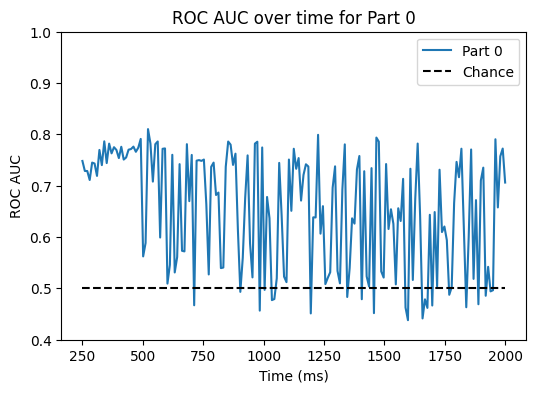

Part 1:   0%|          | 0/75 [00:00<?, ?it/s]

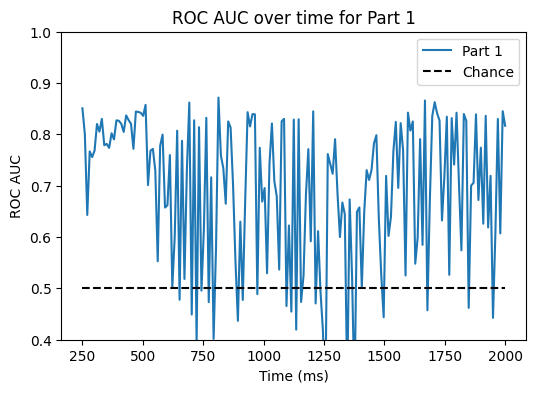

Part 2:   0%|          | 0/75 [00:00<?, ?it/s]

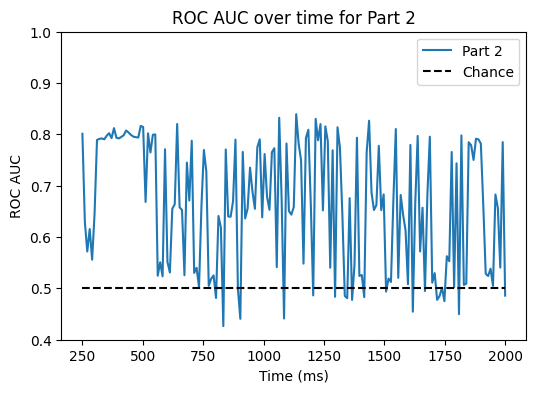

Part 3:   0%|          | 0/75 [00:00<?, ?it/s]

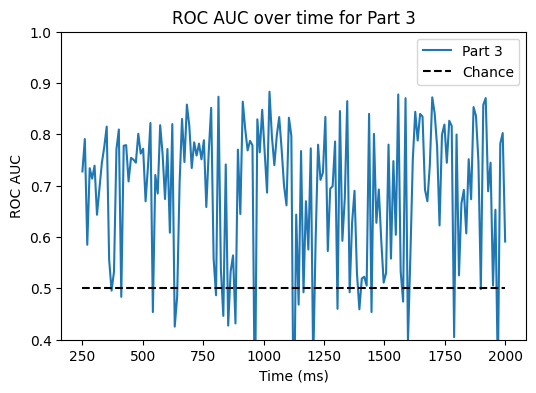

Part 4:   0%|          | 0/75 [00:00<?, ?it/s]

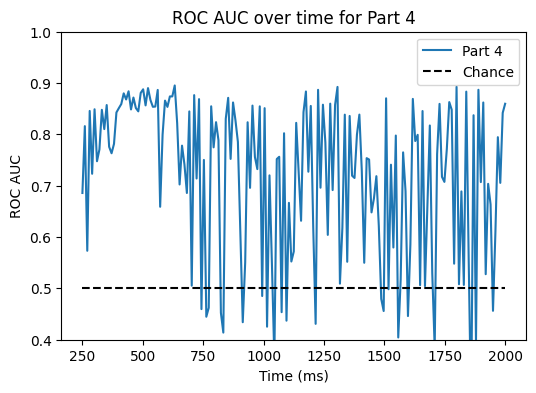

Part 5:   0%|          | 0/75 [00:00<?, ?it/s]

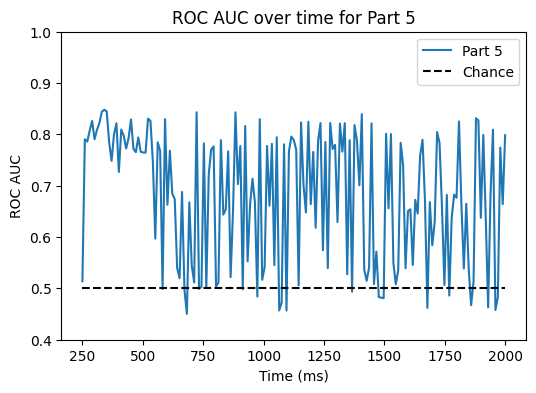

Part 6:   0%|          | 0/75 [00:00<?, ?it/s]

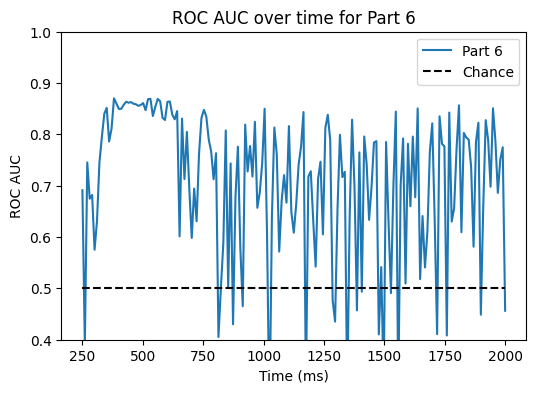

Part 7:   0%|          | 0/75 [00:00<?, ?it/s]

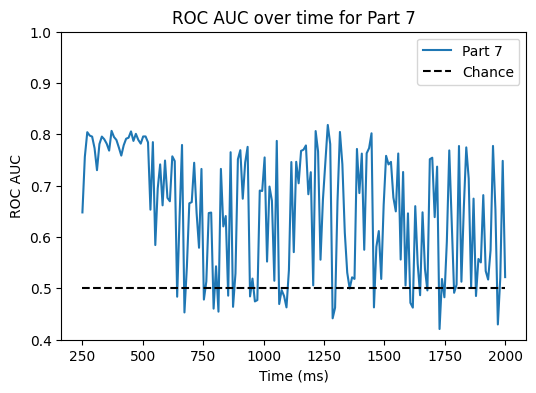

Part 8:   0%|          | 0/75 [00:00<?, ?it/s]

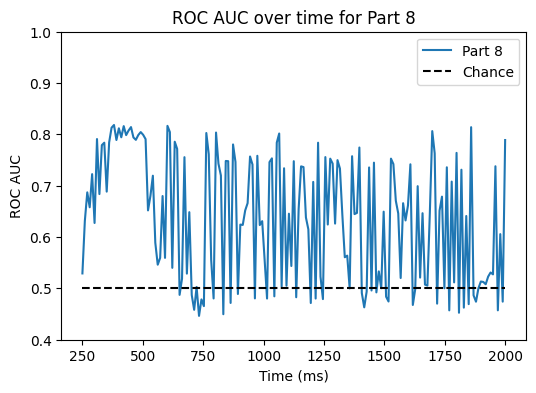

Part 9:   0%|          | 0/75 [00:00<?, ?it/s]

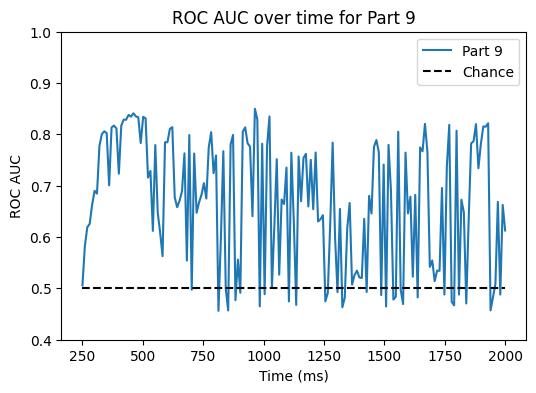

Part 10:   0%|          | 0/75 [00:00<?, ?it/s]

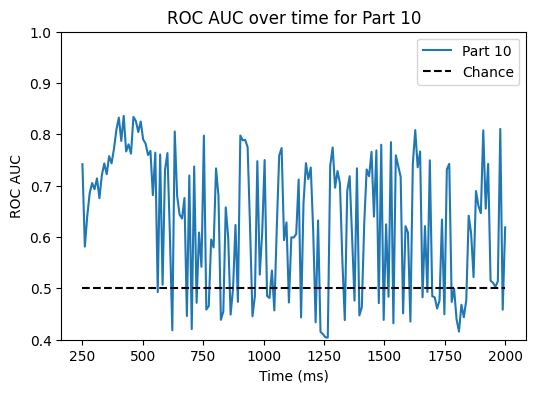

Part 11:   0%|          | 0/75 [00:00<?, ?it/s]

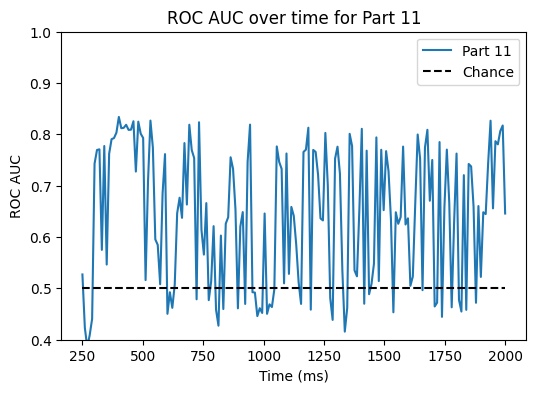

Part 12:   0%|          | 0/75 [00:00<?, ?it/s]

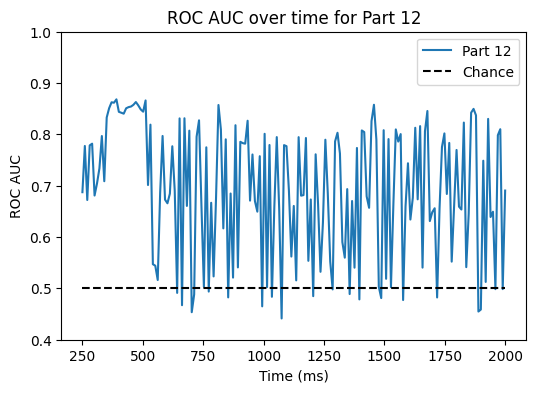

Part 13:   0%|          | 0/75 [00:00<?, ?it/s]

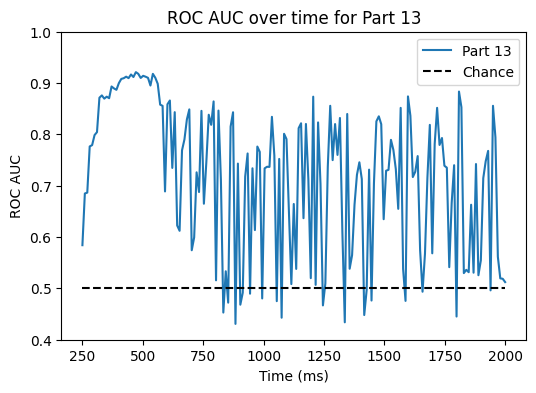

Part 14:   0%|          | 0/75 [00:00<?, ?it/s]

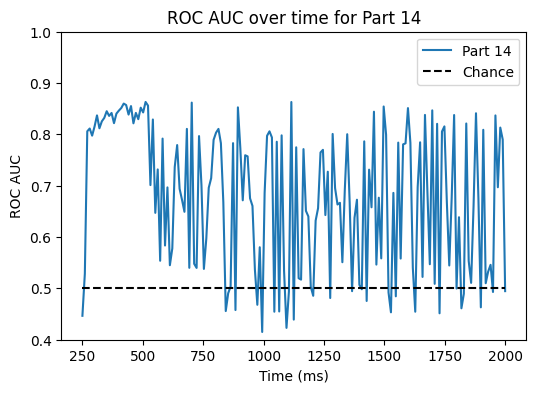

Part 15:   0%|          | 0/75 [00:00<?, ?it/s]

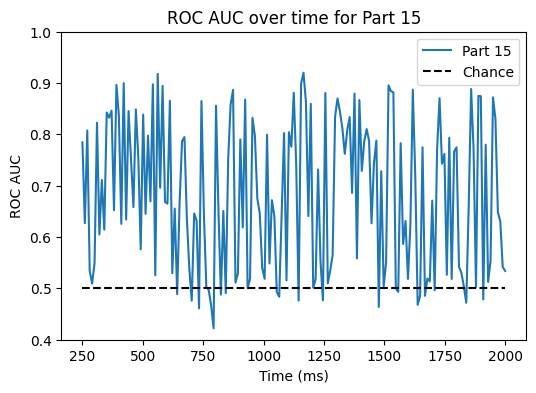

Part 16:   0%|          | 0/75 [00:00<?, ?it/s]

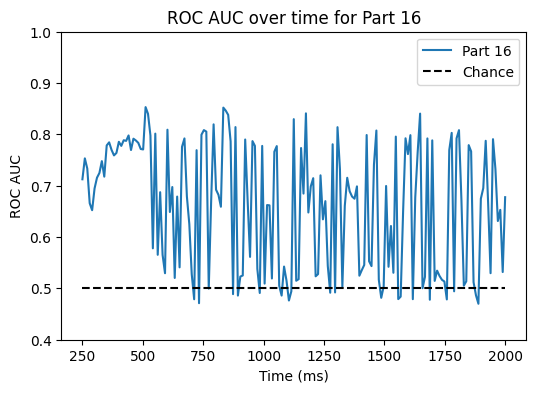

Part 17:   0%|          | 0/75 [00:00<?, ?it/s]

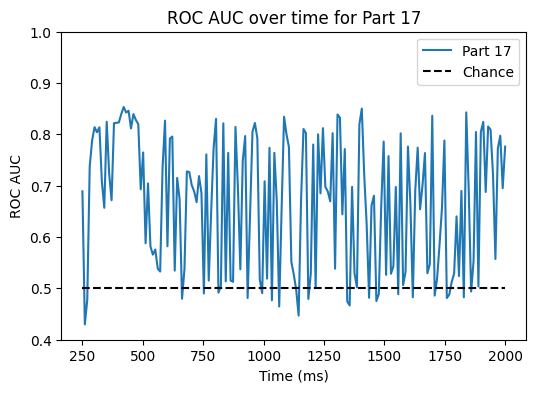

Part 18:   0%|          | 0/75 [00:00<?, ?it/s]

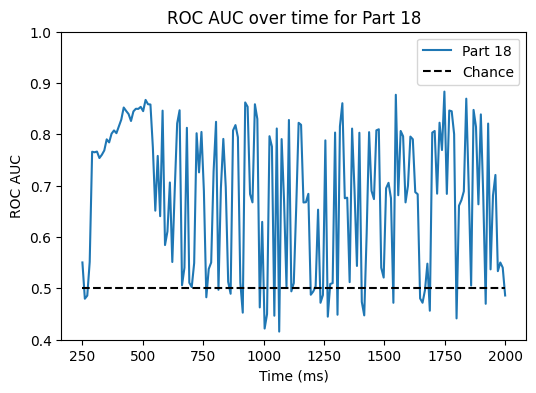

Part 19:   0%|          | 0/75 [00:00<?, ?it/s]

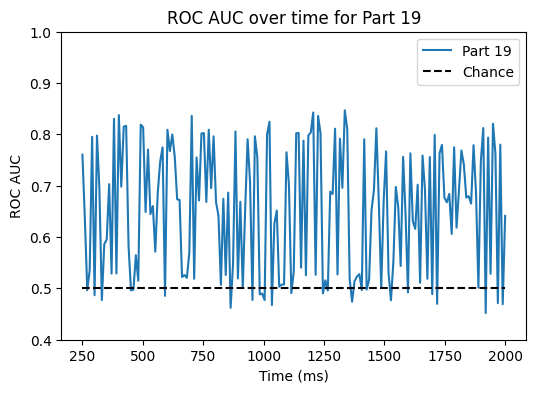

/tmp/ipykernel_79461/973071890.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


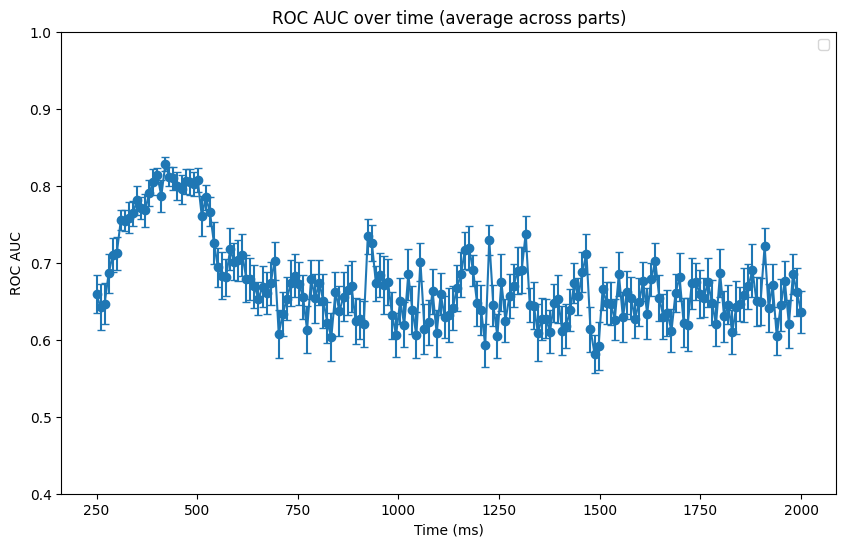

In [14]:
save_folder = 'Behavioral_Predictions_InTime'
# os.makedirs(save_folder, exist_ok=True)


n_new = 75                                      # indices de données 175..250
times_full = np.linspace(250, 2000, 100 + n_new)   # 176 points, grille 10 ms

# # garde-fou : les trajectoires doivent aller jusqu'à l'indice 250
# _cat0 = next(iter(simul_trajectories_dict[0]))
# assert simul_trajectories_dict[0][_cat0].shape[1] >= 75 + 100 + n_new, "Trajectoires trop courtes pour atteindre 2000 ms"

auc_series_full = {}
mixture_series_full = {}
for part in tqdm(range(20)):

    model = models_dict[part]
    auc_serie_new = []
    mixture_serie_new = []
    for t_ind in tqdm(range(n_new), desc=f"Part {part}", leave=False):

        idx = 175 + t_ind
        simul_distributions = {cat: simul_trajectories_dict[part][cat][:, idx].flatten() for cat in simul_trajectories_dict[part]}
        fit_mixture = FitMixture(model, simul_distributions, n=1, fix_resting_state=True, alpha_continuity_penalty_coef=0, fix_lambda_to_zero=False, dt=1, verbose=False)
        distributions = {cat: trajectories_dict[part][cat][:, idx].flatten() for cat in categories}
        auc = model2behaviorAUC(fit_mixture, binarized_audibilities_dict[part], distributions)
        auc_serie_new.append(auc)
        mixture_serie_new.append(fit_mixture)

    auc_series_full[part] = list(auc_series[part]) + auc_serie_new
    mixture_series_full[part] = list(mixture_series[part]) + mixture_serie_new

    plt.figure(figsize=(6, 4))
    plt.plot(times_full, auc_series_full[part], label=f'Part {part}')
    plt.plot(times_full, [0.5] * len(times_full), 'k--', label='Chance')
    plt.title(f'ROC AUC over time for Part {part}')
    plt.xlabel('Time (ms)')
    plt.ylabel('ROC AUC')
    plt.legend()
    plt.ylim(0.4, 1.0)
    plt.savefig(f"{save_folder}/ROC_AUC_over_time_part{part}_SkewedMixture_complete.png", dpi=300)
    plt.show()

# remplace les dicts en mémoire par les versions complètes 250 -> 2000 ms
auc_series = auc_series_full
mixture_series = mixture_series_full

df_auc = pd.DataFrame(auc_series)
df_auc.to_csv(f"{save_folder}/auc_series_SkewedMixture_complete.csv", index=False)

df_mixture = pd.DataFrame(mixture_series)
df_mixture.to_csv(f"{save_folder}/mixture_series_SkewedMixture_complete.csv", index=False)


plt.figure(figsize=(10, 6))
plt.errorbar(times_full, np.nanmean(df_auc.values, axis=1), yerr=np.nanstd(df_auc.values, axis=1) / np.sqrt(df_auc.shape[1]), fmt='-o', capsize=3)
plt.title(f'ROC AUC over time (average across parts)')
plt.xlabel('Time (ms)')
plt.ylabel('ROC AUC')
plt.legend()
plt.ylim(0.4, 1.0)
plt.savefig(f"{save_folder}/ROC_AUC_over_time_average_SkewedMixture_complete.png", dpi=300)
plt.show()

/tmp/ipykernel_79461/762118977.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


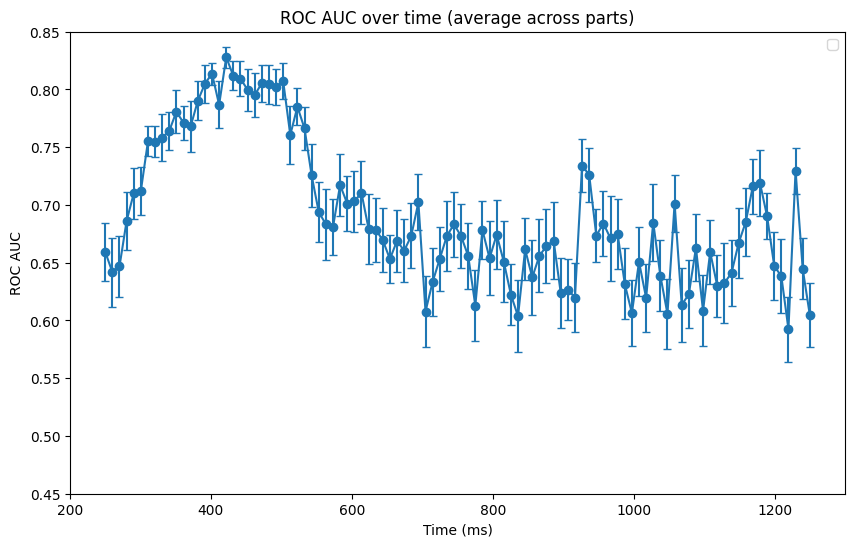

In [12]:
plt.figure(figsize=(10, 6))
plt.errorbar(times, np.nanmean(df_auc.values, axis=1), yerr=np.nanstd(df_auc.values, axis=1) / np.sqrt(df_auc.shape[1]), fmt='-o', capsize=3)
plt.title(f'ROC AUC over time (average across parts)')
plt.xlabel('Time (ms)')
plt.ylabel('ROC AUC')
plt.legend()
plt.ylim(0.45, 0.85)
plt.savefig(f"{save_folder}/ROC_AUC_over_time_average_SkewedMixture.png", dpi=300)
plt.show()

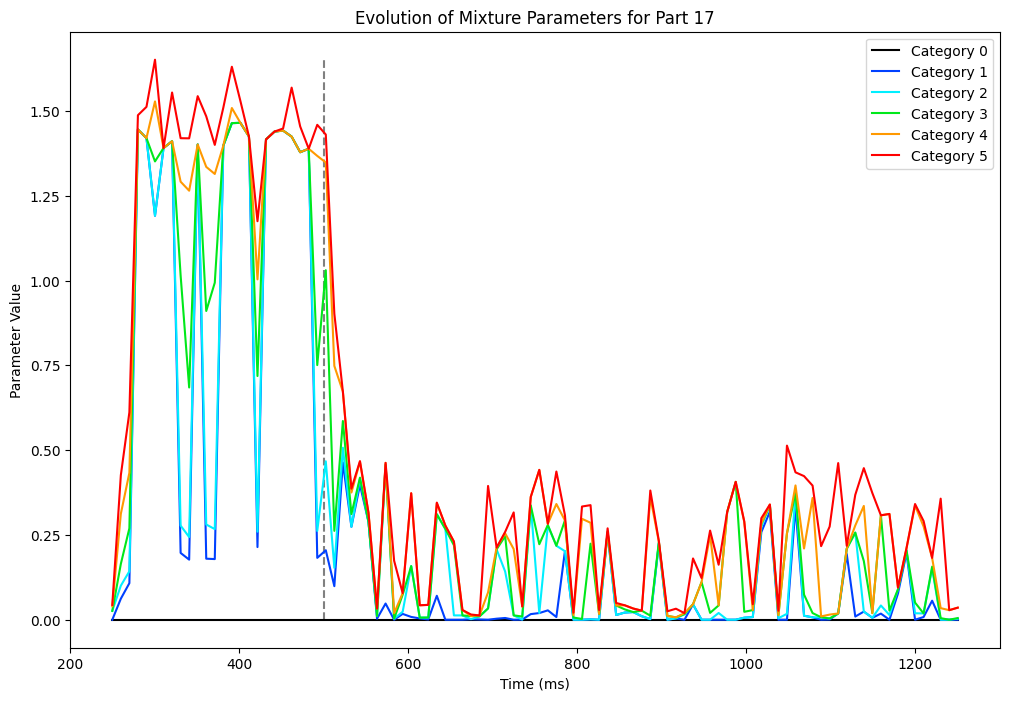

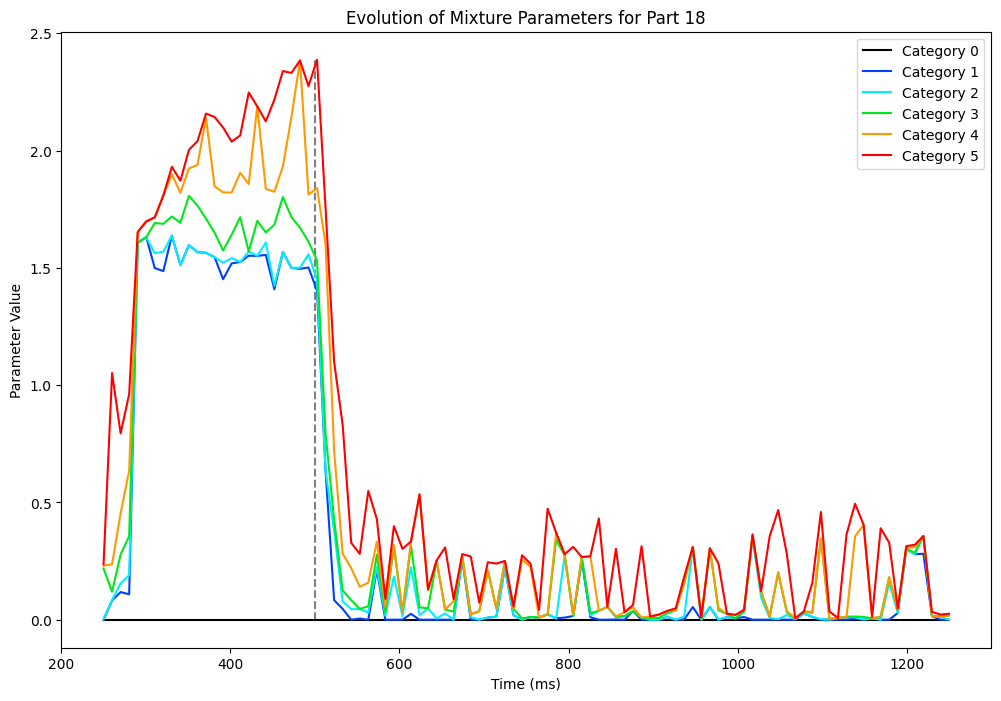

In [9]:
for part in [17, 18]:
    mu1s = {cat: [] for cat in mixture_series[part][0].keys()}
    for t_ind in range(100):
        mixture_fits = mixture_series[part][t_ind]
        for cat in mixture_fits:
            mu1s[cat].append(mixture_fits[cat]['mu1'])

    # plot the evolution of the mixture parameters over time for part 18
    plt.figure(figsize=(12, 8))
    plt.plot([500, 500], [0, np.max(mu1s[5])], linestyle='--', color='gray')
    for cat in mixture_series[part][0].keys():
        plt.plot(times, mu1s[cat], label=f'Category {cat}', color=colormap[cat])
    plt.xlabel('Time (ms)')
    plt.ylabel('Parameter Value')
    plt.title(f'Evolution of Mixture Parameters for Part {part}')
    plt.legend()
    plt.show()

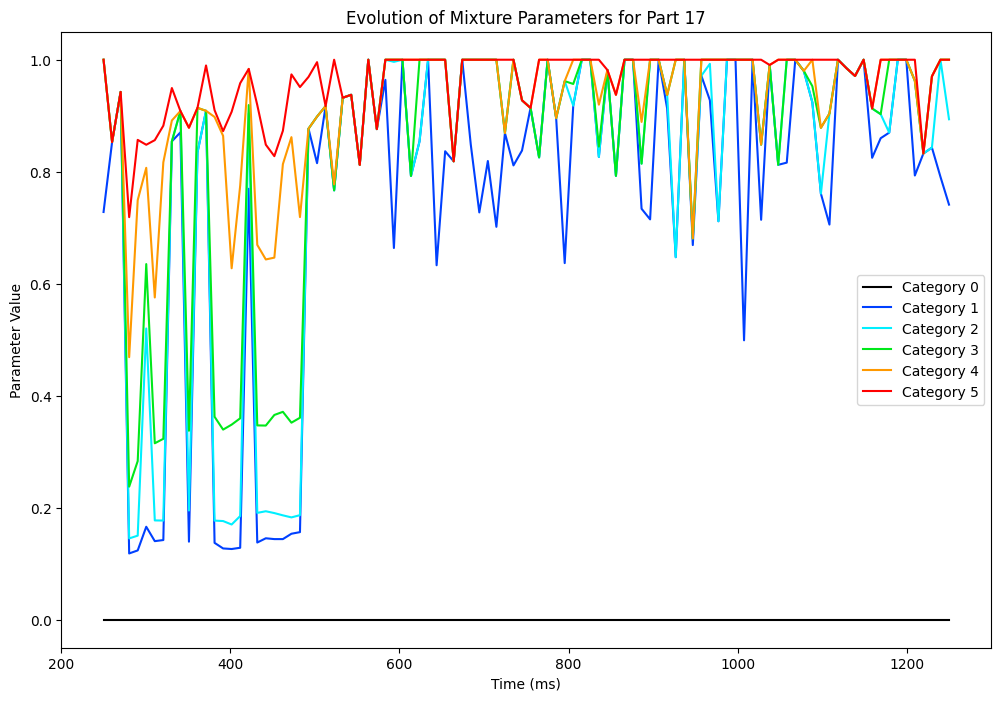

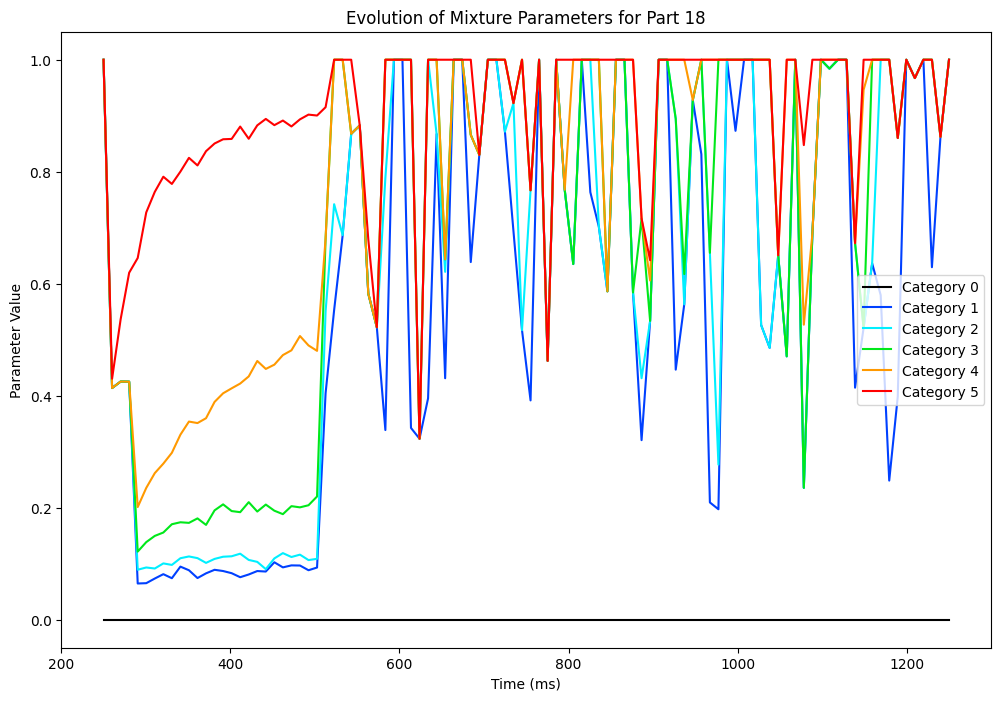

In [10]:
for part in [17, 18]:
    alphas = {cat: [] for cat in mixture_series[part][0].keys()}
    for t_ind in range(100):
        mixture_fits = mixture_series[part][t_ind]
        for cat in mixture_fits:
            alphas[cat].append(mixture_fits[cat]['alpha'])

    # plot the evolution of the mixture parameters over time for part 18
    plt.figure(figsize=(12, 8))
    for cat in mixture_series[part][0].keys():
        plt.plot(times, np.ones_like(alphas[cat]) - alphas[cat], label=f'Category {cat}', color=colormap[cat])
    plt.xlabel('Time (ms)')
    plt.ylabel('Parameter Value')
    plt.title(f'Evolution of Mixture Parameters for Part {part}')
    plt.legend()
    plt.show()

# Compare predicted and empirical psychometric function

In [11]:
for part in range(20):
    print(f'Generating summary plot for participant {part}...')
    mixture_fits = mixture_fits_dict[part]
    binarized_audibilities = binarized_audibilities_dict[part]
    distributions = distributions_dict[part]

    snr_values = SNRs[:len(categories)]
    snr_labels = [('-inf' if not np.isfinite(v) else f'{int(v)} dB') for v in snr_values]
    x_pos = np.arange(len(categories))

    empirical_mean = []
    predicted_mean = []
    empirical_ci_low = []
    empirical_ci_high = []
    n_per_level = []

    for cat in categories:
        y_true = np.asarray(binarized_audibilities[cat], dtype=int)
        x = np.asarray(distributions[cat], dtype=float)
        fit = mixture_fits[cat]

        if x.size == 0 or y_true.size == 0:
            empirical_mean.append(np.nan)
            predicted_mean.append(np.nan)
            empirical_ci_low.append(np.nan)
            empirical_ci_high.append(np.nan)
            n_per_level.append(0)
            continue

        lam    = fit['lambda']
        p_rest = fit['alpha'] * norm.pdf(x, loc=fit['mu0'], scale=fit['sigma0'])
        p_alt  = (1.0 - fit['alpha']) * skewnorm.pdf(x, a=lam, loc=fit['mu1'], scale=fit['sigma1'])
        p_class1 = p_alt / np.maximum(p_rest + p_alt, 1e-300)

        empirical = float(np.mean(y_true))
        predicted = float(np.mean(p_class1))
        n_obs = int(y_true.size)
        se = np.sqrt(max(empirical * (1.0 - empirical), 0.0) / max(n_obs, 1))
        ci_half_width = 1.96 * se

        empirical_mean.append(empirical)
        predicted_mean.append(predicted)
        empirical_ci_low.append(max(0.0, empirical - ci_half_width))
        empirical_ci_high.append(min(1.0, empirical + ci_half_width))
        n_per_level.append(n_obs)

    empirical_mean     = np.asarray(empirical_mean, dtype=float)
    predicted_mean     = np.asarray(predicted_mean, dtype=float)
    empirical_ci_low   = np.asarray(empirical_ci_low, dtype=float)
    empirical_ci_high  = np.asarray(empirical_ci_high, dtype=float)

    prior_mean = np.asarray([1.0 - mixture_fits[cat]['alpha'] for cat in categories], dtype=float)

    fig, ax = plt.subplots(figsize=(9.5, 5.5), constrained_layout=True)

    ax.errorbar(
        x_pos, empirical_mean,
        yerr=[empirical_mean - empirical_ci_low, empirical_ci_high - empirical_mean],
        fmt='o-', color='tab:blue', ecolor='tab:blue',
        elinewidth=1.4, capsize=4, lw=2.2,
        label='Empirical audibility',
    )
    ax.plot(
        x_pos, predicted_mean,
        's--', color='tab:orange', lw=2.2, ms=7,
        label='Predicted class-1 probability',
    )

    FA_rate = empirical_mean[0]
    corrected_predicted_mean = np.zeros_like(predicted_mean)
    for cat in categories:
        corrected_predicted_mean[cat] = predicted_mean[cat] + FA_rate * (1.0 - predicted_mean[cat])
    ax.plot(
        x_pos, corrected_predicted_mean,
        's--', color='tab:green', lw=2.2, ms=7,
        label='Corrected predicted class-1 probability',
    )

    # ax.plot(x_pos, prior_mean, 'd-.', color='tab:green', lw=2.0, ms=7, label='Prior (1 - alpha)')

    for xp, y_emp, y_pred, n_obs in zip(x_pos, empirical_mean, predicted_mean, n_per_level):
        if np.isfinite(y_emp) and np.isfinite(y_pred):
            ax.annotate(
                f'n={n_obs}', (xp, max(y_emp, y_pred)),
                textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9, color='0.35',
            )

    ax.set_title(f'Empirical vs predicted psychometric curve - Part {part}, AUC {roc_auc_dict[part]:.3f}')
    ax.set_xlabel('SNR')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(snr_labels)
    ax.set_ylabel('Probability of audibility / class-1')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis='y', alpha=0.25)
    ax.legend(frameon=False, loc='lower right')

    plt.savefig(f'Behavioral_Predictions_3/2GM_nopenalty_part{part}.png', dpi=300)
    plt.show()

Generating summary plot for participant 0...


KeyError: 0

In [ ]:
# mean AUC for skewed mixture: 0.785 & for 2GM: 0.774
# for resting state fixd at 0: for skewed mixture: 0.830 & for GM: 0.796
avg_auc = np.mean(list(roc_auc_dict.values()))
print(f'Average ROC AUC across all participants: {avg_auc:.3f}')

Average ROC AUC across all participants: 0.792


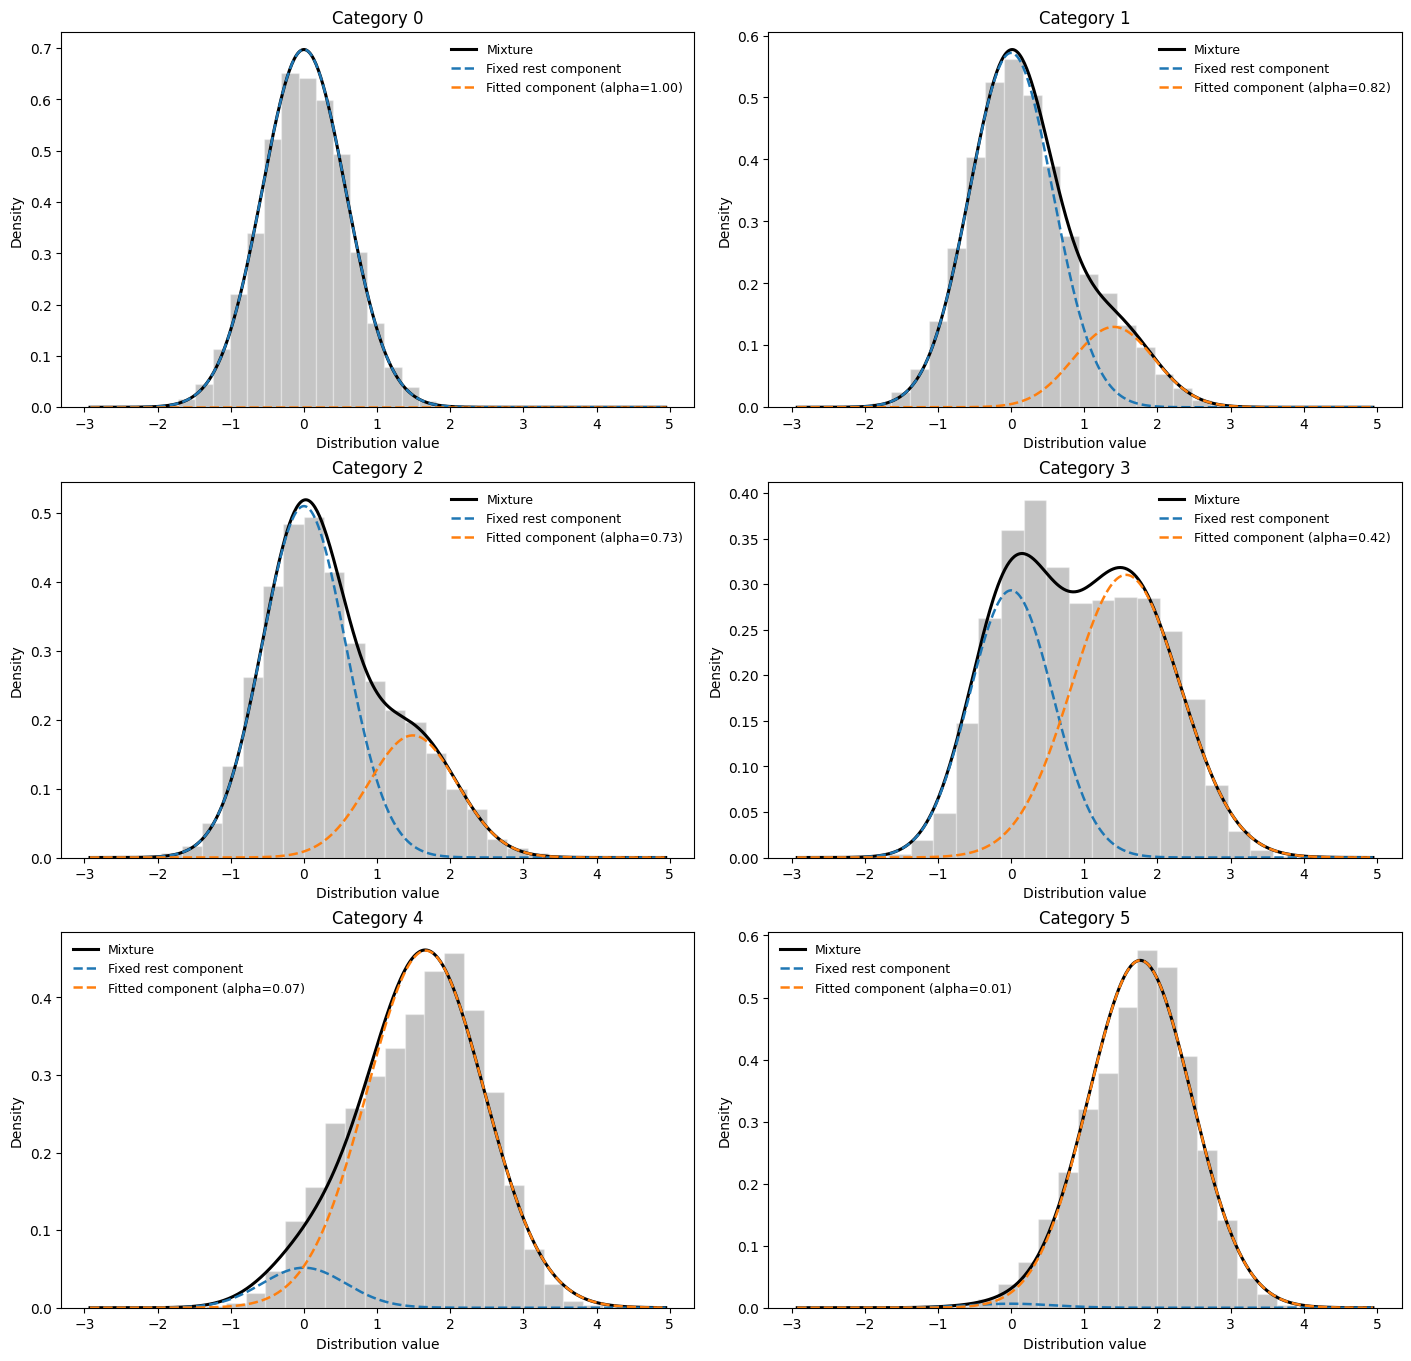

In [ ]:
part = 13

n_cols = 2
n_rows = ceil(len(categories) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

x_grid = np.linspace(
    min(np.min(measured_distributions_dict[part][cat]) for cat in categories) - 0.5,
    max(np.max(measured_distributions_dict[part][cat]) for cat in categories) + 0.5,
    500,
)

for ax, cat in zip(axes, categories):
    x = np.asarray(measured_distributions_dict[part][cat], dtype=float)
    fit = mixture_fits_dict[part][cat]
    mu0    = fit['mu0']
    sigma0 = fit['sigma0']
    alpha  = fit['alpha']
    mu1    = fit['mu1']
    sigma1 = fit['sigma1']
    lam    = fit['lambda']

    ax.hist(x, bins=20, density=True, alpha=0.35, color='0.35', edgecolor='white')

    p0   = norm.pdf(x_grid, loc=mu0, scale=sigma0)
    p1   = skewnorm.pdf(x_grid, a=lam, loc=mu1, scale=sigma1)
    pmix = alpha * p0 + (1.0 - alpha) * p1

    ax.plot(x_grid, pmix,                  color='black',       lw=2.2, label='Mixture')
    ax.plot(x_grid, alpha * p0,            color='tab:blue',    lw=1.8, ls='--', label='Fixed rest component')
    ax.plot(x_grid, (1.0 - alpha) * p1,   color='tab:orange',  lw=1.8, ls='--', label=f'Fitted component (alpha={alpha:.2f})')

    ax.set_title(f'Category {cat}')
    ax.set_xlabel('Distribution value')
    ax.set_ylabel('Density')
    ax.legend(frameon=False, fontsize=9)

for ax in axes[len(categories):]:
    ax.axis('off')

plt.show()